In [2]:
import os
from dotenv import load_dotenv

from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_openai import ChatOpenAI
from langchain.tools import tool

In [3]:
load_dotenv('../.env')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'----> OPENAI_API_KEY: {OPENAI_API_KEY[:3]}***{OPENAI_API_KEY[-3:]}')

LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = os.environ['LANGCHAIN_PROJECT']
print(f'LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')
print(f'----> LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> OPENAI_API_KEY: sk-***tIA
----> LANGCHAIN_API_KEY: lsv***43b
LANGCHAIN_PROJECT: LangGraph ReAct architecture tutorial get started
----> LANGCHAIN_PROJECT: LangGraph ReAct architecture tutorial get started


In [4]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

model = ChatOpenAI(model='gpt-4o', temperature=0)

In [5]:
def make_alternative_graph():
    """Make a tool calling agent"""
    @tool
    def add(a: int, b: int) -> int:
        """Add 2 numbers

        Args:
            a (int): first number
            b (int): second number

        Returns:
            int: the sum of a and b
        """
        return a + b
    
    tool_node = ToolNode([add])
    model_with_tools = model.bind_tools([add])

    def call_llm_model(state: State) -> State:
        return { 'messages': [model_with_tools.invoke(state['messages'])] }
    
    def should_continue(state: State):
        if state['messages'][-1].tool_calls:
            return 'tools'
        return END

    agent_node_name = 'agent'

    graph_workflow = StateGraph(State)

    # Add nodes 
    graph_workflow.add_node(agent_node_name, call_llm_model)
    graph_workflow.add_node('tools', tool_node)

    # Add edges
    graph_workflow.add_edge(START, agent_node_name)
    graph_workflow.add_edge('tools', agent_node_name)
    graph_workflow.add_conditional_edges(agent_node_name, should_continue)

    agent = graph_workflow.compile()
    return agent

alternative_agent = make_alternative_graph()

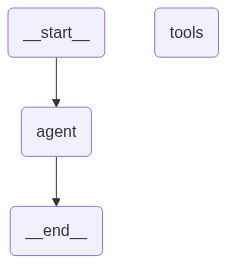

In [6]:
from IPython.display import display, Image

display(Image(alternative_agent.get_graph().draw_mermaid_png()))